In [1]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers_sae import _autoreload
from transformers_sae.replacement_model import make_replacement_model

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 8
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 2

model_id = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
training_dataset = load_dataset(
    "monology/pile-uncopyrighted-parquet",
    split="train",
    streaming=True,
    columns=["text"],
)
validation_dataset = load_dataset(
    "monology/pile-test-val",
    split="validation",
    revision="refs/convert/parquet",
    streaming=True,
    columns=["text"],
)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16
    ),
).to(TRAINING_DEVICE)
model = make_replacement_model(
    model,
    {},
    num_layers=model.config.num_hidden_layers,
    context_length=model.config.max_position_embeddings,
    d_model=model.config.hidden_size,
)

print(model)

/Users/evanlloyd/mechinterp-experiments/transformers_sae/.venv/lib/python3.13/site-packages/codefind/registry.py:46: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, types.FunctionType):


Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

ReplacementModel(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear4bit(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear4bit(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforw

In [2]:
model.device

device(type='mps', index=0)

In [2]:
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
D_SAE = model.d_model * 4
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

In [3]:
import numpy as np

from transformers_sae.sae import (
    SAE,
    DecoderConfig,
    EncoderConfig,
    SAEConfig,
    TopKActivationFunctionConfig,
)
from transformers_sae.training import TrainingConfig, TrainingMethod, fine_tune, train
from transformers_sae.validation import run_validations

saes = {
    layer: SAE(
        SAEConfig(
            d_model=model.d_model,
            d_sae=D_SAE,
            device=TRAINING_DEVICE,
            encoder=EncoderConfig(
                d_model=model.d_model,
                d_sae=D_SAE,
                device=TRAINING_DEVICE,
                activation_function=TopKActivationFunctionConfig(k=TOPK),
            ),
            decoder=DecoderConfig(
                d_model=model.d_model,
                d_sae=D_SAE,
                device=TRAINING_DEVICE,
            ),
        )
    )
    for layer in range(model.num_layers)
}


def linear_decay_during_finetune(frac_trained: float):
    if frac_trained < (1 - FINETUNE_FRACTION):
        return 1.0
    return 1.0 - (frac_trained - (1 - FINETUNE_FRACTION)) / FINETUNE_FRACTION


training_config = TrainingConfig(
    tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
    training_batch_size=TRAINING_BATCH_SIZE,
    num_train_tokens=NUM_TRAINING_TOKENS,
    eval_interval=EVAL_INTERVAL,
    train_layers=list(range(model.num_layers)),
    lr=1e-3,
    interaction_lr=1e-3,
    lr_schedule=linear_decay_during_finetune,  # per Karvonen (2025)
    downstream_reconstruction_weight=1.0,
    reconstruction_weight=1.0,
    balance_reconstruction_losses=True,
    method=TrainingMethod.next_layer,
    finetune_fraction=None,
)

In [4]:
import os

from transformers_sae.activation_cache import build_cache

if TRAINING_CACHE_DIR and (
    not os.path.exists(TRAINING_CACHE_DIR) or not os.listdir(TRAINING_CACHE_DIR)
):
    build_cache(
        TRAINING_CACHE_DIR,
        model,
        tokenizer,
        training_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_TRAINING_TOKENS,
    )

if VALIDATION_CACHE_DIR and (
    not os.path.exists(VALIDATION_CACHE_DIR) or not os.listdir(VALIDATION_CACHE_DIR)
):
    build_cache(
        VALIDATION_CACHE_DIR,
        model,
        tokenizer,
        validation_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_VALIDATION_TOKENS,
    )

In [5]:
training_results = train(
    model,
    tokenizer,
    saes,
    training_dataset,
    training_config,
    cache_dir=TRAINING_CACHE_DIR,
    checkpoints_at=None,
)

Layer 11

  0%|          | 0/1000000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (3180 > 1024). Running this sequence through the model will result in indexing errors


Layer 10

  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  0%|          | 0/1000000 [00:00<?, ?it/s]

Layer 1

  0%|          | 0/1000000 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [8]:
from transformers_sae.validation import run_validations

validations = run_validations(
    model,
    tokenizer,
    training_results.final_saes,
    validation_dataset,
    TOKENIZER_BATCH_SIZE,
    TRAINING_BATCH_SIZE,
    NUM_VALIDATION_TOKENS,
    cache_dir=VALIDATION_CACHE_DIR,
)

Running SAE evals:   0%|          | 0/100000 [00:00<?, ?it/s]

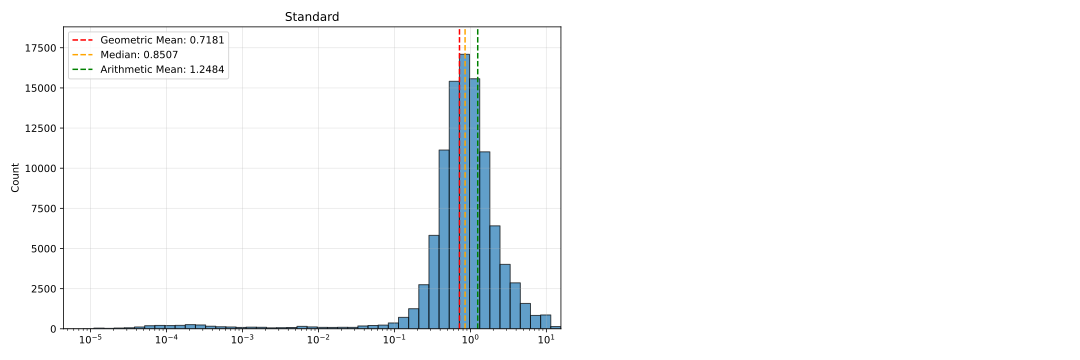

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from transformers_sae.ops import current_plot_to_svg

# Plot histograms of KL divergence for each method
num_methods = 1
ncols = 2
nrows = (num_methods + ncols - 1) // ncols  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))

# Handle case where we have only one row
if nrows == 1:
    axes = axes.reshape(1, -1)
# Handle case where we have only one method
if num_methods == 1:
    axes = axes.reshape(-1)

# Calculate global min/max for consistent bins across all methods
all_kl_values = validations.layer_results[model.num_layers].kl

global_min = np.min(all_kl_values)
global_max = np.max(all_kl_values)
log_bins = np.logspace(np.log10(global_min), np.log10(global_max), 50)

# Calculate global y-axis limits
max_frequency = 0
kl_values = validations.layer_results[model.num_layers].kl
counts, _ = np.histogram(kl_values, bins=log_bins)
max_frequency = max(max_frequency, np.max(counts))

for i, method in zip((0,), (TrainingMethod.standard,)):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]
    
    kl_values = validations.layer_results[model.num_layers].kl

    # Create histogram with consistent bins
    ax.hist(kl_values, bins=log_bins, alpha=0.7, edgecolor="black")
    ax.set_xscale("log")
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(0, max_frequency * 1.1)
    # ax.set_xlabel(r"")
    ax.set_ylabel("Count")
    ax.set_title(method.value)
    ax.grid(True, alpha=0.3)

    # Compute log-normal distribution statistics
    log_kl_values = np.log(np.clip(kl_values, min=1e-9))
    log_mean = np.mean(log_kl_values)
    log_std = np.std(log_kl_values)
    
    # Geometric mean and geometric standard deviation for log-normal distribution
    geometric_mean = np.exp(log_mean)
    geometric_std = np.exp(log_std)
    
    # Median is the same as geometric mean for log-normal
    median_kl = np.median(kl_values)
    
    # Arithmetic mean
    mean_kl = np.mean(kl_values)
    
    ax.axvline(geometric_mean, color="red", linestyle="--", label=f"Geometric Mean: {geometric_mean:.4f}")
    ax.axvline(
        median_kl, color="orange", linestyle="--", label=f"Median: {median_kl:.4f}"
    )
    ax.axvline(
        mean_kl, color="green", linestyle="--", label=f"Arithmetic Mean: {mean_kl:.4f}"
    )
    
    ax.legend()

# Hide any unused subplots
for i in range(num_methods, nrows * ncols):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]
    ax.set_visible(False)

plt.tight_layout()
current_plot_to_svg("validation_kl_dist")

In [5]:
from transformers_sae.validation import generate_with_replacement

generate_with_replacement(
    model, tokenizer, "The capital of France,", {}# training_results.final_saes
)

 Paris, is a city that is full of history and culture. It is also a city that is full of beautiful architecture. The Eiffel Tower is one of the most famous landmarks in Paris. It is a symbol of the city and is a must-see for any visitor. The Eiffel Tower is located in the city of Paris, France. It is a symbol of the city and is a must-see 
*** Generation aborted by user ***
